In [1]:
import torch
import csv
from matplotlib import pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

In [10]:
with open("data\mnist_train.csv", "r") as read_obj:
    csv_reader = csv.reader(read_obj)
    train = list(csv_reader)
train = train[1:]
train = [[int(train[i][j]) for j in range(len(train[0]))] for i in range(len(train))]
train = torch.tensor(train, dtype = torch.float32)


In [11]:
train_Y = train[:,0].long()
train_X = train[:,1:]

dataset = TensorDataset(train_X, train_Y)

batch_size = 16
dataloader = DataLoader(dataset, batch_size = batch_size, shuffle = True)




288
tensor(7)


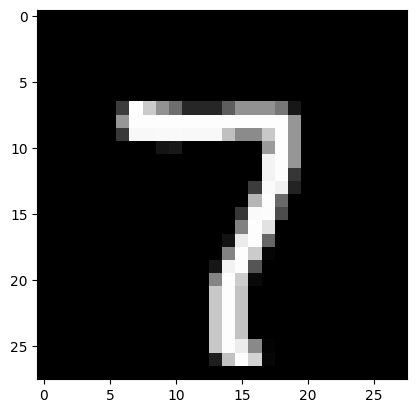

In [12]:
n = int(torch.floor(1000*torch.rand(1)))
test = train_X[n].reshape((28,28))
print(n)
print(train_Y[n])
plt.imshow(test, cmap = "gray")

In [22]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.linear_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )
        

    def forward(self, x):
        x = self.linear_stack(x)
        return x
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net().to(device)

learning_rate = 0.001
lossF = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

In [23]:
def train(epoch):
    model.train()
    running_loss = 0.0
    running_acc = 0.0

    for i, (inputs, labels) in enumerate(dataloader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = lossF(outputs, labels)

        with torch.no_grad():
            preds = torch.argmax(outputs, dim = 1)
            correct = (preds == labels)
            accuracy = correct.float().sum()
            running_acc += accuracy

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    print(f'Epoch {epoch}, Loss: {running_loss:.4f}, Acc: {running_acc/60000}')
    running_loss = 0


In [24]:
epochs = 10
for epoch in range(epochs):
    train(epoch)

Epoch 0, Loss: 1344.2683, Acc: 0.9136666655540466
Epoch 1, Loss: 779.2593, Acc: 0.9460166692733765
Epoch 2, Loss: 646.6250, Acc: 0.9563166499137878
Epoch 3, Loss: 613.3349, Acc: 0.9612833261489868
Epoch 4, Loss: 515.8646, Acc: 0.9665666818618774
Epoch 5, Loss: 467.8915, Acc: 0.9698500037193298
Epoch 6, Loss: 464.0703, Acc: 0.9717000126838684
Epoch 7, Loss: 469.9571, Acc: 0.9717166423797607
Epoch 8, Loss: 437.9128, Acc: 0.9737833142280579
Epoch 9, Loss: 388.3082, Acc: 0.9760500192642212
